# CNN Feature Extraction with Filters and Pooling
## Task 1: Implement Edge Detection Using Convolution 
Write a Python script using NumPy and OpenCV (cv2) to apply edge detection on an image using a Sobel filter.
- Load a grayscale image (you can use any sample image).
- Apply the Sobel filter for edge detection in the x-direction and y-direction.
- Display the original image and the filtered images.
- Use the following Sobel filters:


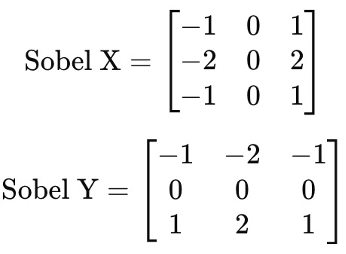

 
## Task 2: Implement Max Pooling and Average Pooling (15 points)
Write a Python script using TensorFlow/Keras to demonstrate Max Pooling and Average Pooling.
- Create a random 4x4 matrix as an input image.
- Apply a 2x2 Max Pooling operation.
- Apply a 2x2 Average Pooling operation.
- Print the original matrix, max-pooled matrix, and average-pooled matrix.


Expected Output

Task1: Edge Detection using Sobel Filter
- Display three images:
    1.	Original Image
    2.	Edge detection using Sobel-X
    3.	Edge detection using Sobel-Y
Task2: Pooling Operations on Random 4×4 Matrix
- Printed original matrix, max pooled matrix, and average pooled matrix.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the image as grayscale using OpenCV
image = cv2.imread("lena.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image could not be loaded.")


In [4]:
# Define the Sobel Filters

# Sobel X filter
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)


# Sobel Y filter
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)


In [5]:
# Apply the Sobel filters
edge_x = cv2.filter2D(
    image,
    cv2.CV_64F,
    sobel_x
)

edge_y = cv2.filter2D(
    image,
    cv2.CV_64F,
    sobel_y
)

In [6]:
# Convert negative/positive edge values into displayable pixel values
edge_x = cv2.convertScaleAbs(edge_x)
edge_y = cv2.convertScaleAbs(edge_y)

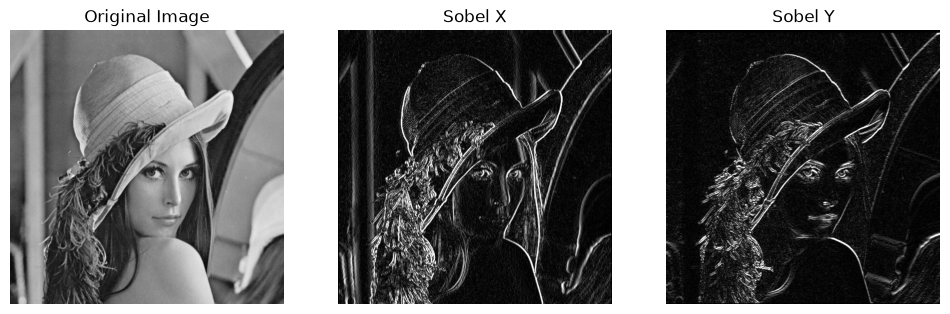

In [7]:
# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edge_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edge_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.show()

## Task 2

In [9]:
import tensorflow as tf

from tensorflow.keras.layers import MaxPooling2D,AveragePooling2D

In [17]:
#Random seed
np.random.seed(42)

input_matrix = np.random.randint(1,50,size=(4,4)).astype(np.float32)

print(input_matrix)


[[39. 29. 15. 43.]
 [ 8. 21. 39. 19.]
 [23. 11. 11. 24.]
 [36. 40. 24.  3.]]


In [23]:
# Reshaping the tensor

input_tensor = input_matrix.reshape(1, 4, 4, 1)

# Remove the extra dimension
input_tensor = input_tensor.squeeze()
print("Input Tensor:\n", input_tensor)


Input Tensor:
 [[39. 29. 15. 43.]
 [ 8. 21. 39. 19.]
 [23. 11. 11. 24.]
 [36. 40. 24.  3.]]


In [21]:
# 2x2 Max Pooling
max_pool = MaxPooling2D(
    pool_size=(2, 2)
)

max_output = max_pool(input_tensor)


# 2x2 Average Pooling
avg_pool = AveragePooling2D(
    pool_size=(2, 2)
)

avg_output = avg_pool(input_tensor)


In [22]:
# Remove unnecessary batch/channel dimensions
max_output = max_output.numpy().squeeze()
avg_output = avg_output.numpy().squeeze()


print("\nMax Pooled Matrix:")
print(max_output)

print("\nAverage Pooled Matrix:")
print(avg_output)


Max Pooled Matrix:
[[39. 43.]
 [40. 24.]]

Average Pooled Matrix:
[[24.25 29.  ]
 [27.5  15.5 ]]
